# CosmicFish Pie v1.0   

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
snscolors=sns.color_palette("colorblind")
from copy import deepcopy

In [3]:
envkey = 'OMP_NUM_THREADS'
# Set this environment variable to the number of available cores in your machine, 
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(8)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  8


In [4]:
from cosmicfishpie.fishermatrix import cosmicfish
from cosmicfishpie.utilities.utils import printing as upr

In [5]:
upr.debug = False

# CosmicFish as a cosmology calculator

## Define input, options, fiducial and observables

In [6]:
fiducial = {"Omegam":0.3111,
            "Omegab":0.04897,
            "h":0.6766,
            "ns":0.9665,
            "sigma8":0.815584,
            #"As" : 2.1098301595078886e-09,
            "w0":-1.0,
            "wa":0.,
            "mnu":0.0,
            #"Neff":3.044,
            "num_massive_neutrinos" : 0,
            "num_nu_massive": 0,
            "num_nu_massless": 3.044,
            "tau": 0.0561,
            'kmax': 10,
            'extrap_kmax': None
            }

options = {
                'accuracy': 1,
                'feedback': 1,
                'code' : '',
                'derivatives' : '3PT',
                'outroot': '',
                'survey_name': 'Euclid',
                'specs_dir' : '../cosmicfishpie/configs/default_survey_specifications/',        
                'cosmo_model' : 'LCDM',
                'camb_config_yaml' : '../cosmicfishpie/configs/default_boltzmann_yaml_files/camb/default.yaml',
                'symbolic_config_yaml' : '../cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/default.yaml',
                'results_dir' : 'results_symb/'
                }
freepars = {
            'Omegam':0.01,
            'Omegab':0.01,
            'h': 0.01,
            'ns': 0.01,
            'sigma8': 0.01
            }

In [7]:
options['cosmo_model'] = 'LCDM'
options['code'] = 'camb'
options['outroot'] = options['cosmo_model']+'_'+options['code']
obses = [['WL']]
fish_camb=dict()
cosmo_camb = dict()
for obs in obses:
    obstr = '-'.join(obs)
    cosmo_camb[obstr] = cosmicfish.FisherMatrix(fiducialpars=fiducial,
                        options=options,
                        observables=obs,
                        freepars=freepars,
                        surveyName=options['survey_name'],
                        cosmoModel=options['cosmo_model'])
    #fish_camb[obstr] = cosmo_camb[obstr].compute()

****************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

****************************************************************
 This is the new Python version of the CosmicFish code.
****************************************************************

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   1.93 s


In [8]:
options['cosmo_model'] = 'LCDM'
options['code'] = 'symbolic'
options['outroot'] = options['cosmo_model']+'_'+options['code']
yaml_nonlin = ['default', 'halofit+', 'syren']
yaml_path='../cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/'
obses = [['WL']]
fish_symb = dict()
cosmo_symb = dict()
runFishers = False
for obs in obses:
    for ynl in yaml_nonlin:
        options['symbolic_config_yaml'] = yaml_path+ynl+'.yaml'
        obstr = '-'.join(obs)+'_'+ynl
        cosmo_symb[obstr] = cosmicfish.FisherMatrix(fiducialpars=fiducial,
                        options=options,
                        observables=obs,
                        freepars=freepars,
                        surveyName=options['survey_name'],
                        cosmoModel=options['cosmo_model'])
        if runFishers:
            fish_symb[obstr] = cosmo_symb[obstr].compute()

****************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

****************************************************************
 This is the new Python version of the CosmicFish code.
****************************************************************

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   0.11 s
****************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

****************************************************************
 This is the new Python version of the CosmicFish code.
****************************************************************

  -> Computing cosmology at the fiducial p

In [9]:
print(cosmo_symb.keys())
print(cosmo_camb.keys())
## Comparison plots

dict_keys(['WL_default', 'WL_halofit+', 'WL_syren'])
dict_keys(['WL'])


## Comparison plots

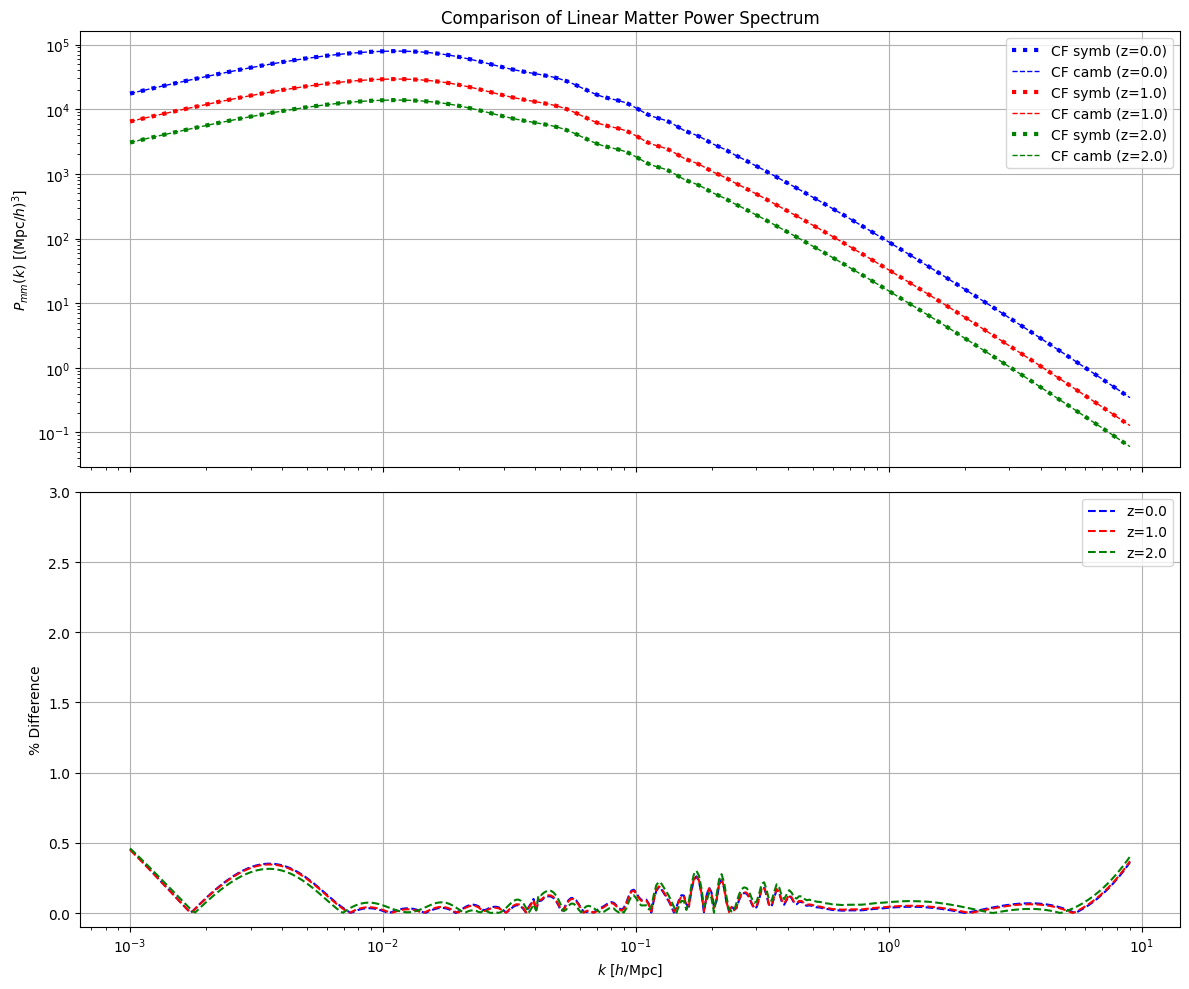

In [10]:
thresh = 1e-10
zz = cosmo_symb['WL_syren'].fiducialcosmo.results.zgrid
kmpc = cosmo_symb['WL_syren'].fiducialcosmo.kgrid
z_list = [0., 1.0, 2.0]  # Three different redshifts

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Colors and line styles
colors = ['blue', 'red', 'green']
linestyles = [':', '--', '-']

nonlinear = False

for i, z in enumerate(z_list):
    symb_quant = np.clip(cosmo_symb['WL_syren'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    camb_quant = np.clip(cosmo_camb['WL'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    percentage_diff = np.abs(100 * (symb_quant - camb_quant) / camb_quant)
    
    # Power spectrum plot
    ax1.loglog(kmpc, symb_quant, color=colors[i], ls=linestyles[0], 
               label=f'CF symb (z={z})', lw=3)
    ax1.loglog(kmpc, camb_quant, color=colors[i], ls=linestyles[1], 
               label=f'CF camb (z={z})', lw=1)
    
    # Percentage difference plot
    ax2.semilogx(kmpc, percentage_diff, color=colors[i], ls=linestyles[1], 
                 label=f'z={z}')

ax1.set_ylabel(r'$P_{mm}(k) \ [(\mathrm{Mpc}/h)^3]$')
if nonlinear:
    ax1.set_title('Comparison of Nonlinear Matter Power Spectrum')
else:
    ax1.set_title('Comparison of Linear Matter Power Spectrum')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$')
ax2.set_ylabel('% Difference')
ax2.set_ylim(-0.1,3.0)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

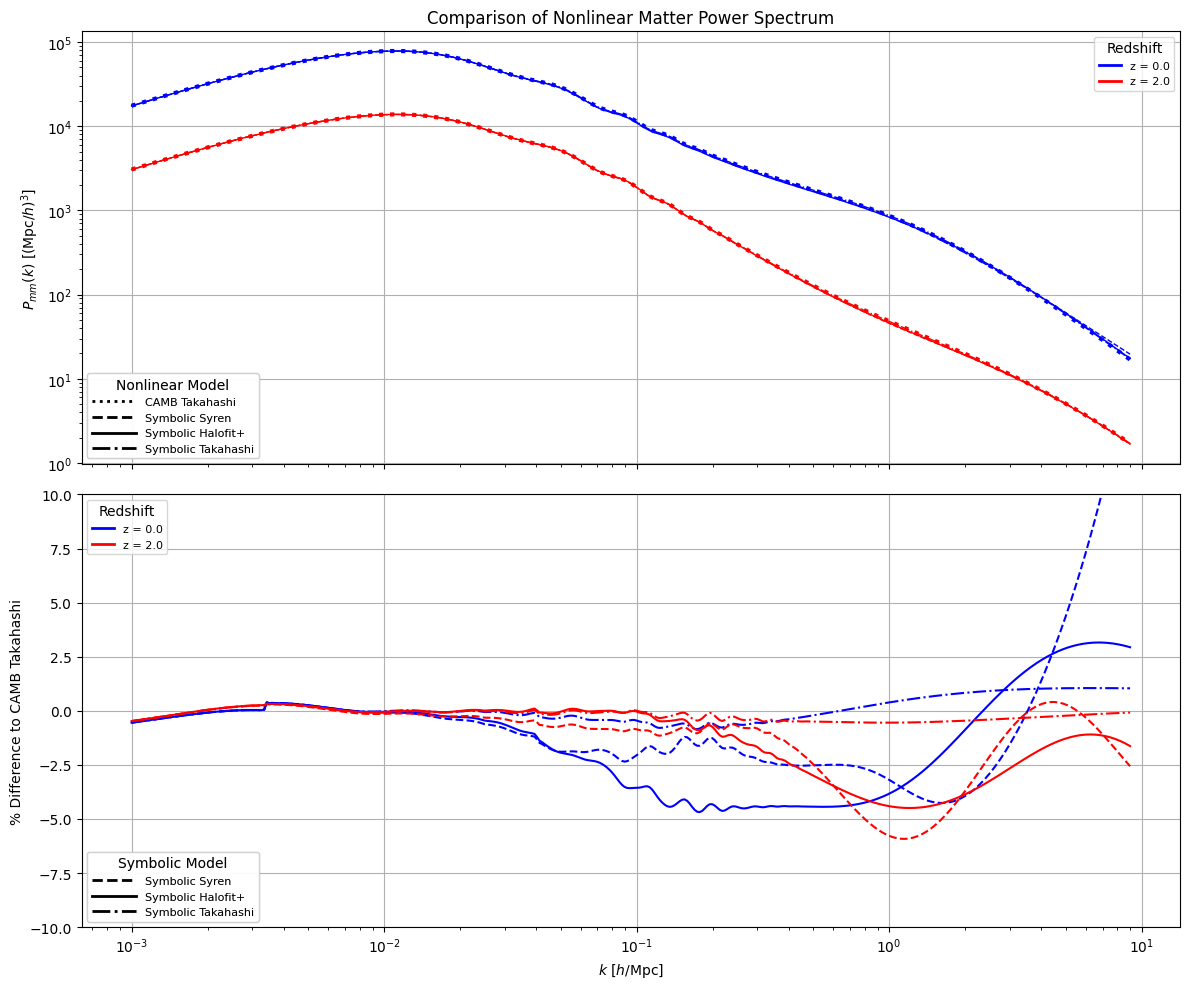

In [11]:
from matplotlib.lines import Line2D

thresh = 1e-10
zz = cosmo_symb['WL_syren'].fiducialcosmo.results.zgrid
kmpc = cosmo_symb['WL_syren'].fiducialcosmo.kgrid
z_list = [0., 2.0]  # different redshifts

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Colors and line styles
colors = ['blue', 'red']
linestyles = [':', '--', '-', '-.']
models = ['CAMB Takahashi', 'Symbolic Syren', 'Symbolic Halofit+', 'Symbolic Takahashi']

nonlinear = True

for i, z in enumerate(z_list):
    symb_quant = np.clip(cosmo_symb['WL_syren'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    symb_hfp = np.clip(cosmo_symb['WL_halofit+'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    symb_taka = np.clip(cosmo_symb['WL_default'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    camb_quant = np.clip(cosmo_camb['WL'].fiducialcosmo.Pmm(z, kmpc, nonlinear=nonlinear), thresh, None)
    percentage_diff = (100 * (symb_quant - camb_quant) / camb_quant)
    percentage_diff_hfp = (100 * (symb_hfp - camb_quant) / camb_quant)
    percentage_diff_taka = (100 * (symb_taka - camb_quant) / camb_quant)
    
    # Power spectrum plot
    ax1.loglog(kmpc, camb_quant, color=colors[i], ls=linestyles[0], lw=3)
    ax1.loglog(kmpc, symb_quant, color=colors[i], ls=linestyles[1], lw=1)
    ax1.loglog(kmpc, symb_hfp, color=colors[i], ls=linestyles[2], lw=1)
    ax1.loglog(kmpc, symb_taka, color=colors[i], ls=linestyles[3], lw=1)
    
    # Percentage difference plot
    ax2.semilogx(kmpc, percentage_diff, color=colors[i], ls=linestyles[1])
    ax2.semilogx(kmpc, percentage_diff_hfp, color=colors[i], ls=linestyles[2])
    ax2.semilogx(kmpc, percentage_diff_taka, color=colors[i], ls=linestyles[3])

# Create legends for ax1
z_legend_elements = [Line2D([0], [0], color=c, lw=2, label=f'z = {z}') for c, z in zip(colors, z_list)]
z_legend = ax1.legend(handles=z_legend_elements, loc='upper right', title='Redshift', fontsize=8)
ax1.add_artist(z_legend)

model_legend_elements = [Line2D([0], [0], color='black', ls=ls, lw=2, label=model, markevery=10, markersize=15) for ls, model in zip(linestyles, models)]
model_legend = ax1.legend(handles=model_legend_elements, loc='lower left', title='Nonlinear Model', fontsize=8, handlelength=4)
ax1.add_artist(model_legend)

ax1.set_ylabel(r'$P_{mm}(k) \ [(\mathrm{Mpc}/h)^3]$')
if nonlinear:
    ax1.set_title('Comparison of Nonlinear Matter Power Spectrum')
else:
    ax1.set_title('Comparison of Linear Matter Power Spectrum')
ax1.grid(True)

# Create legends for ax2
z_legend_elements_2 = [Line2D([0], [0], color=c, lw=2, label=f'z = {z}') for c, z in zip(colors, z_list)]
z_legend_2 = ax2.legend(handles=z_legend_elements_2, loc='upper left', title='Redshift', fontsize=8)
ax2.add_artist(z_legend_2)

model_legend_elements_2 = [Line2D([0], [0], color='black', ls=ls, lw=2, label=model, markevery=10, markersize=15) for ls, model in zip(linestyles[1:], models[1:])]
model_legend_2 = ax2.legend(handles=model_legend_elements_2, loc='lower left', 
                            title='Symbolic Model', fontsize=8, handlelength=4)
ax2.add_artist(model_legend_2)

ax2.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$')
ax2.set_ylabel('% Difference to CAMB Takahashi')
ax2.set_ylim(-10., 10.0)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
print(min(cosmo_camb['WL'].fiducialcosmo.kgrid), max(cosmo_camb['WL'].fiducialcosmo.kgrid), len(cosmo_camb['WL'].fiducialcosmo.kgrid))
print(min(cosmo_symb['WL_syren'].fiducialcosmo.kgrid), max(cosmo_symb['WL_syren'].fiducialcosmo.kgrid), len(cosmo_symb['WL_syren'].fiducialcosmo.kgrid))

7.204447991898633e-06 10.16741496219635 709
0.001 9.0 400


In [13]:
options

{'accuracy': 1,
 'feedback': 1,
 'code': 'symbolic',
 'derivatives': '3PT',
 'outroot': 'LCDM_symbolic',
 'survey_name': 'Euclid',
 'specs_dir': '../cosmicfishpie/configs/default_survey_specifications/',
 'cosmo_model': 'LCDM',
 'camb_config_yaml': '../cosmicfishpie/configs/default_boltzmann_yaml_files/camb/default.yaml',
 'symbolic_config_yaml': '../cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/syren.yaml',
 'results_dir': 'results_symb/',
 'camb_path': '/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/camb',
 'specs_dir_default': '/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/configs/default_survey_specifications',
 'survey_specs': 'ISTF-Optimistic',
 'survey_name_photo': 'Euclid-Photometric-ISTF-Pessimistic',
 'survey_name_spectro': 'Euclid-Spectroscopic-ISTF-Pessimistic',
 'survey_name_radio_photo': 'SKA1-Photometric-Redbook-Optimistic',
 'survey_name_radio_spectro': 'SKA1-Spectroscopic-Redbook-Optimistic',
 'surve

In [14]:
options['cosmo_model'] = 'LCDM'
options['code'] = 'symbolic'
options['outroot'] = options['cosmo_model']+'_'+options['code']
yaml_nonlin = ['default', 'halofit+', 'syren']
yaml_path='../cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/'
obses = [['WL']]

In [43]:
class observPk:
    def __init__(self, options, code='symbolic', 
                 nonlinflag='default', observable=['WL'],
                 at_z=0, at_kgrid=None):
        options['cosmo_model'] = 'LCDM'
        options['code'] = code
        options['outroot'] = options['cosmo_model']+'_'+options['code']
        yaml_path='../cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/'
        options['symbolic_config_yaml'] = yaml_path+nonlinflag+'.yaml'
        cambflag=''
        if nonlinflag != 'default':
            cambflag = '_'+nonlinflag
        options['camb_config_yaml'] = '../cosmicfishpie/configs/default_boltzmann_yaml_files/camb/default'+cambflag+'.yaml'
        self.options = options
        self.observable = observable
        self.cf= cosmicfish.FisherMatrix(fiducialpars=fiducial,
                        options=options,
                        observables=observable,
                        freepars=freepars,
                        surveyName=options['survey_name'],
                        cosmoModel=options['cosmo_model'])
        self.fiducialcosmo = self.cf.fiducialcosmo
        self.at_z = at_z
        self.at_kgrid = at_kgrid
        if at_kgrid is None:
            self.kgrid = self.fiducialcosmo.kgrid
        else:
            self.kgrid = at_kgrid
        self.zgrid = self.fiducialcosmo.results.zgrid
        self.Pk_fid = self.fiducialcosmo.Pmm(self.at_z, self.kgrid, nonlinear=True)
    def Pk_obj(self, cosmodic):
        self.options['feedback'] = 0
        cosmo = cosmicfish.FisherMatrix(fiducialpars=cosmodic,
                        options=self.options,
                        observables=self.observable,
                        freepars=freepars,
                        surveyName=self.options['survey_name'],
                        cosmoModel=self.options['cosmo_model'])
        self.Pk = cosmo.fiducialcosmo.Pmm(self.at_z, self.kgrid, nonlinear=True)
        return self.Pk

In [44]:
newpars = deepcopy(fiducial)
newpars['Omegam'] = 0.32
print(newpars)

{'Omegam': 0.32, 'Omegab': 0.04897, 'h': 0.6766, 'ns': 0.9665, 'sigma8': 0.815584, 'w0': -1.0, 'wa': 0.0, 'mnu': 0.0, 'num_massive_neutrinos': 0, 'num_nu_massive': 0, 'num_nu_massless': 3.044, 'tau': 0.0561, 'kmax': 10, 'extrap_kmax': None}


## Compute Derivatives

In [45]:
from cosmicfishpie.fishermatrix import derivatives as cfd

In [46]:
freepars

{'Omegam': 0.01, 'Omegab': 0.01, 'h': 0.01, 'ns': 0.01, 'sigma8': 0.01}

In [90]:
observ_sym_taka = observPk(options, code='symbolic', nonlinflag='syren', observable=['WL'], at_z=0.,
                           at_kgrid=np.logspace(-3, np.log10(9), 400))
print(observ_sym_taka.kgrid.shape)
print(min(observ_sym_taka.kgrid), max(observ_sym_taka.kgrid))
print(observ_sym_taka.zgrid.shape)
derivs_sym_taka = cfd.derivatives(observ_sym_taka.Pk_obj, fiducial, freeparams=freepars, derivatives_type='4PT_FWD',
                         observables_type='plain', feed_lvl=1)
print(derivs_sym_taka.result.keys())
print(derivs_sym_taka.result['Omegam'].shape)

(400,)
0.001 9.0
(100,)

  +++ Computing 4pt forward derivative on Omegam

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on Omegam done! in :  0.51 s

  +++ Computing 4pt forward derivative on Omegab

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on Omegab done! in :  0.53 s

  +++ Computing 4pt forward derivative on h

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on h done! in :  0.52 s

  +++ Computing 4pt forward derivative on ns

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on ns done! in :  0.51 s

  +++ Computing 4pt forward derivative on sigma8

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on sigma8 done! in :  0.51 s
dict_keys(['Omegam', 'Omegab', 'h', 'ns', 'sigma8'])
(400,)


In [88]:
observ_camb_taka = observPk(options, code='camb', nonlinflag='default', observable=['WL'], at_z=0., 
                             at_kgrid=np.logspace(-3, np.log10(9), 400))
print(observ_camb_taka.kgrid.shape)
print(min(observ_camb_taka.kgrid), max(observ_camb_taka.kgrid))
print(observ_camb_taka.zgrid.shape)
derivs_camb_taka = cfd.derivatives(observ_camb_taka.Pk_obj, fiducial, freeparams=freepars, derivatives_type='4PT_FWD',
                         observables_type='plain', feed_lvl=1)
print(derivs_camb_taka.result.keys())
print(derivs_camb_taka.result['Omegam'].shape)

(400,)
0.001 9.0
(100,)

  +++ Computing 4pt forward derivative on Omegam

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on Omegam done! in :  7.75 s

  +++ Computing 4pt forward derivative on Omegab

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on Omegab done! in :  8.55 s

  +++ Computing 4pt forward derivative on h

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on h done! in :  10.51 s

  +++ Computing 4pt forward derivative on ns

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on ns done! in :  10.84 s

  +++ Computing 4pt forward derivative on sigma8

  ++++ Computing observables at 4 steps

In class: derivatives  Derivative on sigma8 done! in :  11.04 s
dict_keys(['Omegam', 'Omegab', 'h', 'ns', 'sigma8'])
(400,)


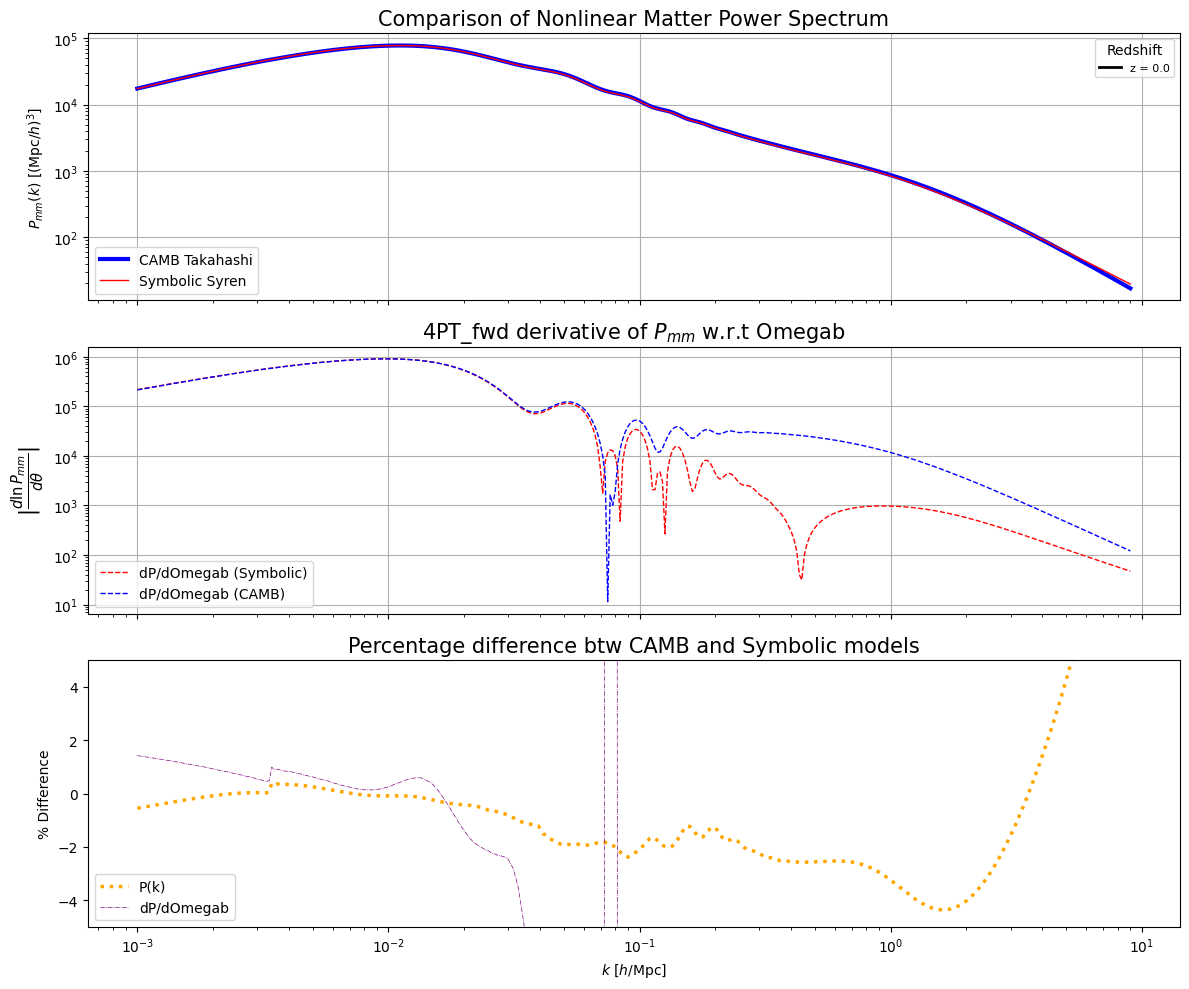

In [91]:
from matplotlib.lines import Line2D

thresh = 1e-10
z_list = [0.]  # different redshifts

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

kkgrid = np.logspace(-3, np.log10(9), 400)

# Colors and line styles
colors = ['blue', 'red']
linestyles = ['-', '--', ':', '-.']
#models = ['CAMB Takahashi', 'Symbolic Syren', 'Symbolic Halofit+', 'Symbolic Takahashi']

parameter = 'Omegab'

sym_model = 'Syren' #'Takahashi' #'Syren'
camb_model = 'Takahashi' #'HMcode'
nonlinear = True

for i, z in enumerate(z_list):
    symb_quant = observ_sym_taka.Pk_fid
    camb_quant = observ_camb_taka.Pk_fid
    percentage_diff_pk = (2 * 100 * (symb_quant - camb_quant) / (camb_quant+symb_quant))

    sym_deriv = np.abs(derivs_sym_taka.result[parameter])
    camb_deriv = np.abs(derivs_camb_taka.result[parameter])
    percentage_diff_deriv = (2 * 100 * ((sym_deriv - camb_deriv)) / (camb_deriv+sym_deriv ))
    
    # Power spectrum plot
    ax1.loglog(kkgrid, camb_quant, color=colors[0], ls=linestyles[0], lw=3, label='CAMB '+camb_model)
    ax1.loglog(kkgrid, symb_quant, color=colors[1], ls=linestyles[0], lw=1, label='Symbolic '+sym_model)

    #Derivative plot
    ax2.loglog(kkgrid, sym_deriv, color=colors[1], ls=linestyles[1], lw=1, label='dP/d'+parameter+' (Symbolic)')
    ax2.loglog(kkgrid, camb_deriv, color=colors[0], ls=linestyles[1], lw=1, label='dP/d'+parameter+' (CAMB)')
    
    # Percentage difference plot
    ax3.semilogx(kkgrid, percentage_diff_pk, color='orange', ls=linestyles[2], label='P(k)', lw=2.5)
    ax3.semilogx(kkgrid, percentage_diff_deriv, color='purple', ls=linestyles[3], label='dP/d'+parameter, lw=.5)

# Create legends for ax1
z_legend_elements = [Line2D([0], [0], color='k', lw=2, label=f'z = {z}') for c, z in zip(colors, z_list)]
z_legend = ax1.legend(handles=z_legend_elements, loc='upper right', title='Redshift', fontsize=8)
ax1.add_artist(z_legend)
#model_legend_elements = [Line2D([0], [0], color='black', ls=ls, lw=2, label=model, markevery=10, markersize=15) for ls, model in zip(linestyles, models)]
#model_legend = ax1.legend(handles=model_legend_elements, loc='lower left', title='Nonlinear Model', fontsize=8, handlelength=4)
#ax1.add_artist(model_legend)

ax1.set_ylabel(r'$P_{mm}(k) \ [(\mathrm{Mpc}/h)^3]$')
ax3.set_ylabel('% Difference')
if nonlinear:
    ax1.set_title('Comparison of Nonlinear Matter Power Spectrum', fontsize=15)
else:
    ax1.set_title('Comparison of Linear Matter Power Spectrum', fontsize=15)
ax1.grid(True)

# Create legends for ax2
#z_legend_elements_2 = [Line2D([0], [0], color=c, lw=2, label=f'z = {z}') for c, z in zip(colors, z_list)]
#z_legend_2 = ax2.legend(handles=z_legend_elements_2, loc='upper left', title='Redshift', fontsize=8)
#ax2.add_artist(z_legend_2)

#model_legend_elements_2 = [Line2D([0], [0], color='black', ls=ls, lw=2, label=model, markevery=10, markersize=15) for ls, model in zip(linestyles[1:], models[1:])]
#model_legend_2 = ax2.legend(handles=model_legend_elements_2, loc='lower left', 
#                            title='Symbolic Model', fontsize=8, handlelength=4)
#ax2.add_artist(model_legend_2)
ax2.set_title(r'4PT_fwd derivative of $P_{mm}$ w.r.t '+parameter, fontsize=15)
ax2.set_ylabel(r'$|\frac{d\ln P_{mm}}{d\theta}|$', fontsize=15)
ax3.set_title('Percentage difference btw CAMB and Symbolic models', fontsize=15)
ax1.legend(fontsize=10, loc='lower left')
ax2.legend(fontsize=10, loc='lower left')   
ax3.legend(fontsize=10, loc='lower left')
ax3.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$')
#ax2.set_ylim(-10., 10.0)
ax3.set_ylim(-5., 5.0)
ax2.grid(True)

plt.tight_layout()
plt.show()

## Compute Fisher Matrices

### Compare Fisher Matrices

In [13]:
from cosmicfishpie.analysis import fisher_matrix as fm
from cosmicfishpie.analysis import fisher_plotting as fpp
from cosmicfishpie.analysis import colors
import cosmicfishpie.analysis.fisher_plot_analysis as fpa
colorlist = [colors.nice_colors(ii) for ii in range(8)]
import numpy as np

In [14]:
fish_symb['WL_syren'].name = 'Euclid-WL-Symb-Syren'
fish_symb['WL_halofit+'].name = 'Euclid-WL-Symb-Halofit+'
fish_symb['WL_default'].name = 'Euclid-WL-Symb-Takahashi'
fish_camb={}
fish_camb['WL'] = fm.fisher_matrix(file_name='./results_symb/CosmicFish_v1.0_LCDM_camb_WL_fishermatrix.txt')
fish_camb['WL'].name = 'Euclid-WL-CAMB-Takahashi'
parstomarg = ['Omegab','sigma8']

In [15]:
parstomarg = ['Omegab','sigma8']
FishesWL = [fish_symb['WL_syren'], fish_symb['WL_halofit+'], fish_symb['WL_default'], fish_camb['WL']]
fishlist = fpa.CosmicFish_FisherAnalysis(FishesWL)
fishlist.compare_fisher_results(parstomarg=parstomarg)

----
Fisher Name:  Euclid-WL-Symb-Syren
Fisher FoM in Omegab,sigma8: 4338.395
Parameter Omegam    , fiducial:    0.311, 1-sigma error:   0.0105, percent error:      3.4%
Parameter Omegab    , fiducial:    0.049, 1-sigma error:   0.0231, percent error:     47.1%
Parameter h         , fiducial:    0.677, 1-sigma error:   0.2191, percent error:     32.4%
Parameter ns        , fiducial:    0.967, 1-sigma error:   0.0923, percent error:      9.5%
Parameter sigma8    , fiducial:    0.816, 1-sigma error:   0.0102, percent error:      1.2%
Parameter AIA       , fiducial:    1.720, 1-sigma error:   4.0645, percent error:    236.3%
Parameter betaIA    , fiducial:    2.170, 1-sigma error:   1.0845, percent error:     50.0%
Parameter etaIA     , fiducial:   -0.410, 1-sigma error:   2.5954, percent error:    633.0%
----
Fisher Name:  Euclid-WL-Symb-Halofit+
Fisher FoM in Omegab,sigma8: 5358.465
Parameter Omegam    , fiducial:    0.311, 1-sigma error:   0.0064, percent error:      2.1%
Parameter Ome

### Plot Fisher Matrices

In [16]:
plot_options = {'fishers_list': FishesWL, 
                'colors': colorlist,
                'fish_labels': [fish.name for fish in FishesWL],
                'plot_pars': ['Omegab', 'sigma8', 'h', 'ns', 'Omegam', 'AIA', 'etaIA'],
                'axis_custom_factors': {'all': 4},  ## Axis limits cover 3-sigma bounds of first Fisher matrix
                'plot_method': 'Gaussian',
                'file_format': '.pdf',   ##file format for all the plots
                'outpath' : 'results_symb/plots/',  ## directory where to store the files, if non-existent, it will be created
                'outroot':'Euclid-WL-Symb_vs_CAMB-LCDM-Nonlin'  ## file name root for all the plots, extra names can be added individually
                } 
fish_plotter = fpp.fisher_plotting(**plot_options)
#fish_plotter.compare_errors(options={'yrang' : [-500, 500], 'ncol_legend': 2})

results_symb/plots  exists already
Fisher matrix loaded, label name:  Euclid-WL-Symb-Syren
Fisher matrix loaded, label name:  Euclid-WL-Symb-Halofit+
Fisher matrix loaded, label name:  Euclid-WL-Symb-Takahashi
Fisher matrix loaded, label name:  Euclid-WL-CAMB-Takahashi


Entering plotting routine
{'Omegam': [0.2689453456943976, 0.3532546543056024], 'Omegab': [-0.043342233310638675, 0.14128223331063866], 'h': [-0.19985601743431947, 1.5530560174343195], 'ns': [0.597423272244194, 1.335576727755806], 'sigma8': [0.7749655584202255, 0.8562024415797744], 'AIA': [-14.537914455925941, 17.97791445592594], 'betaIA': [0.0009035675533528575, 4.339096432446647], 'etaIA': [-10.791495246140636, 9.971495246140636]}


/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/analysis/fisher_plotting.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  g.fig.savefig(
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


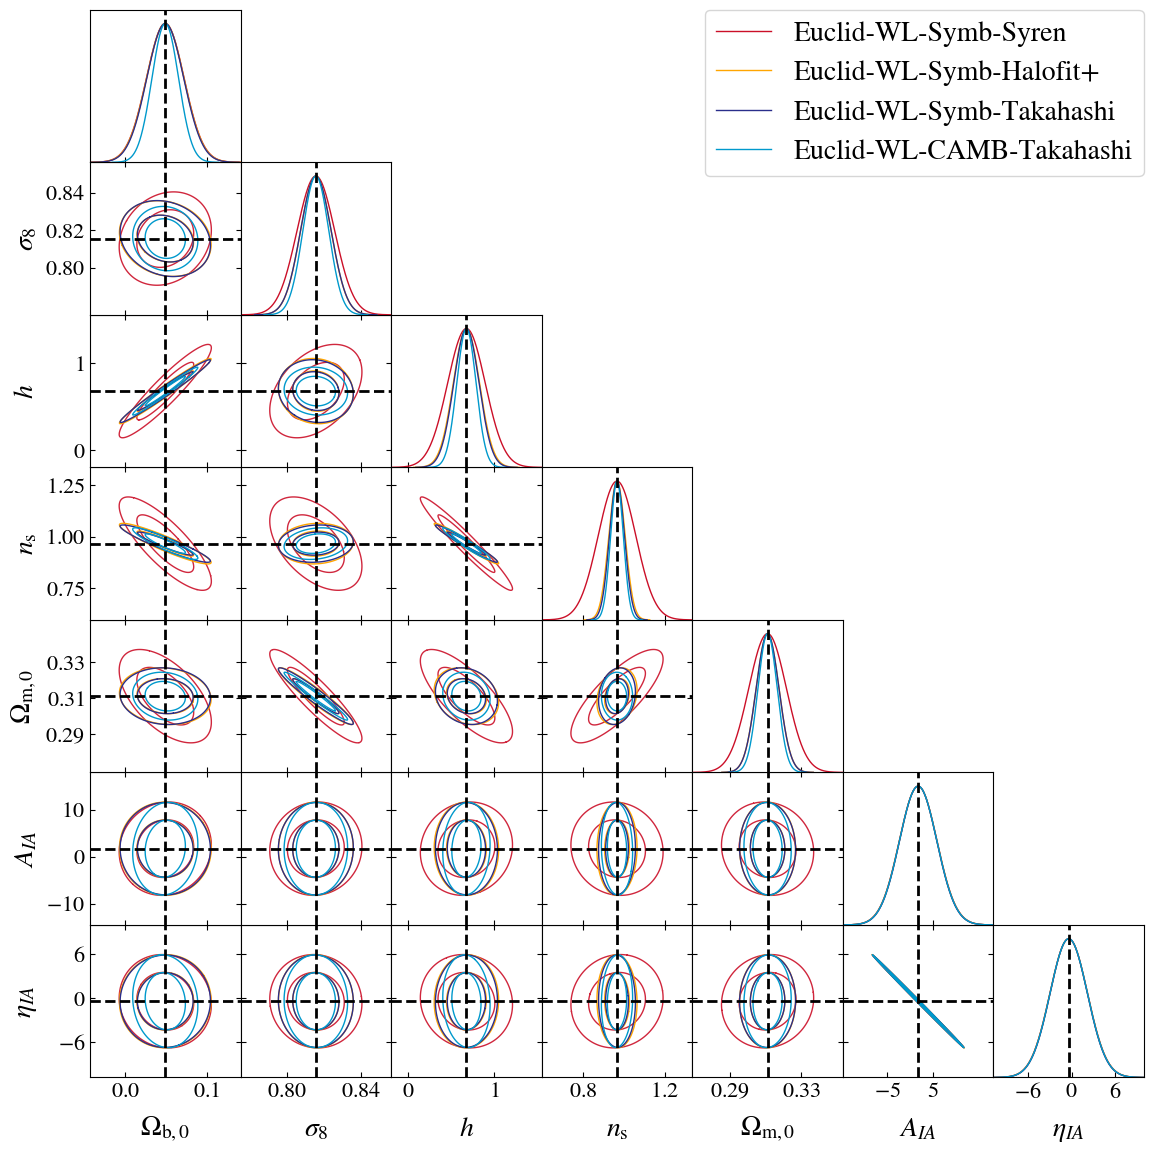

In [17]:
fish_plotter.plot_fisher(filled=[False, False, False, False])

('Fishers names: ', ['Euclid-WL-Symb-Syren', 'Euclid-WL-Symb-Halofit+', 'Euclid-WL-Symb-Takahashi', 'Euclid-WL-CAMB-Takahashi'])
('parameters to plot: ', ['Omegab', 'sigma8', 'h', 'ns', 'Omegam', 'AIA', 'etaIA'])
X tick labels ---> :   ['\\Omega_{{\\rm b}, 0}', '\\sigma_8', 'h', 'n_{\\rm s}', '\\Omega_{{\\rm m}, 0}', 'A_{IA}', '\\eta_{IA}']


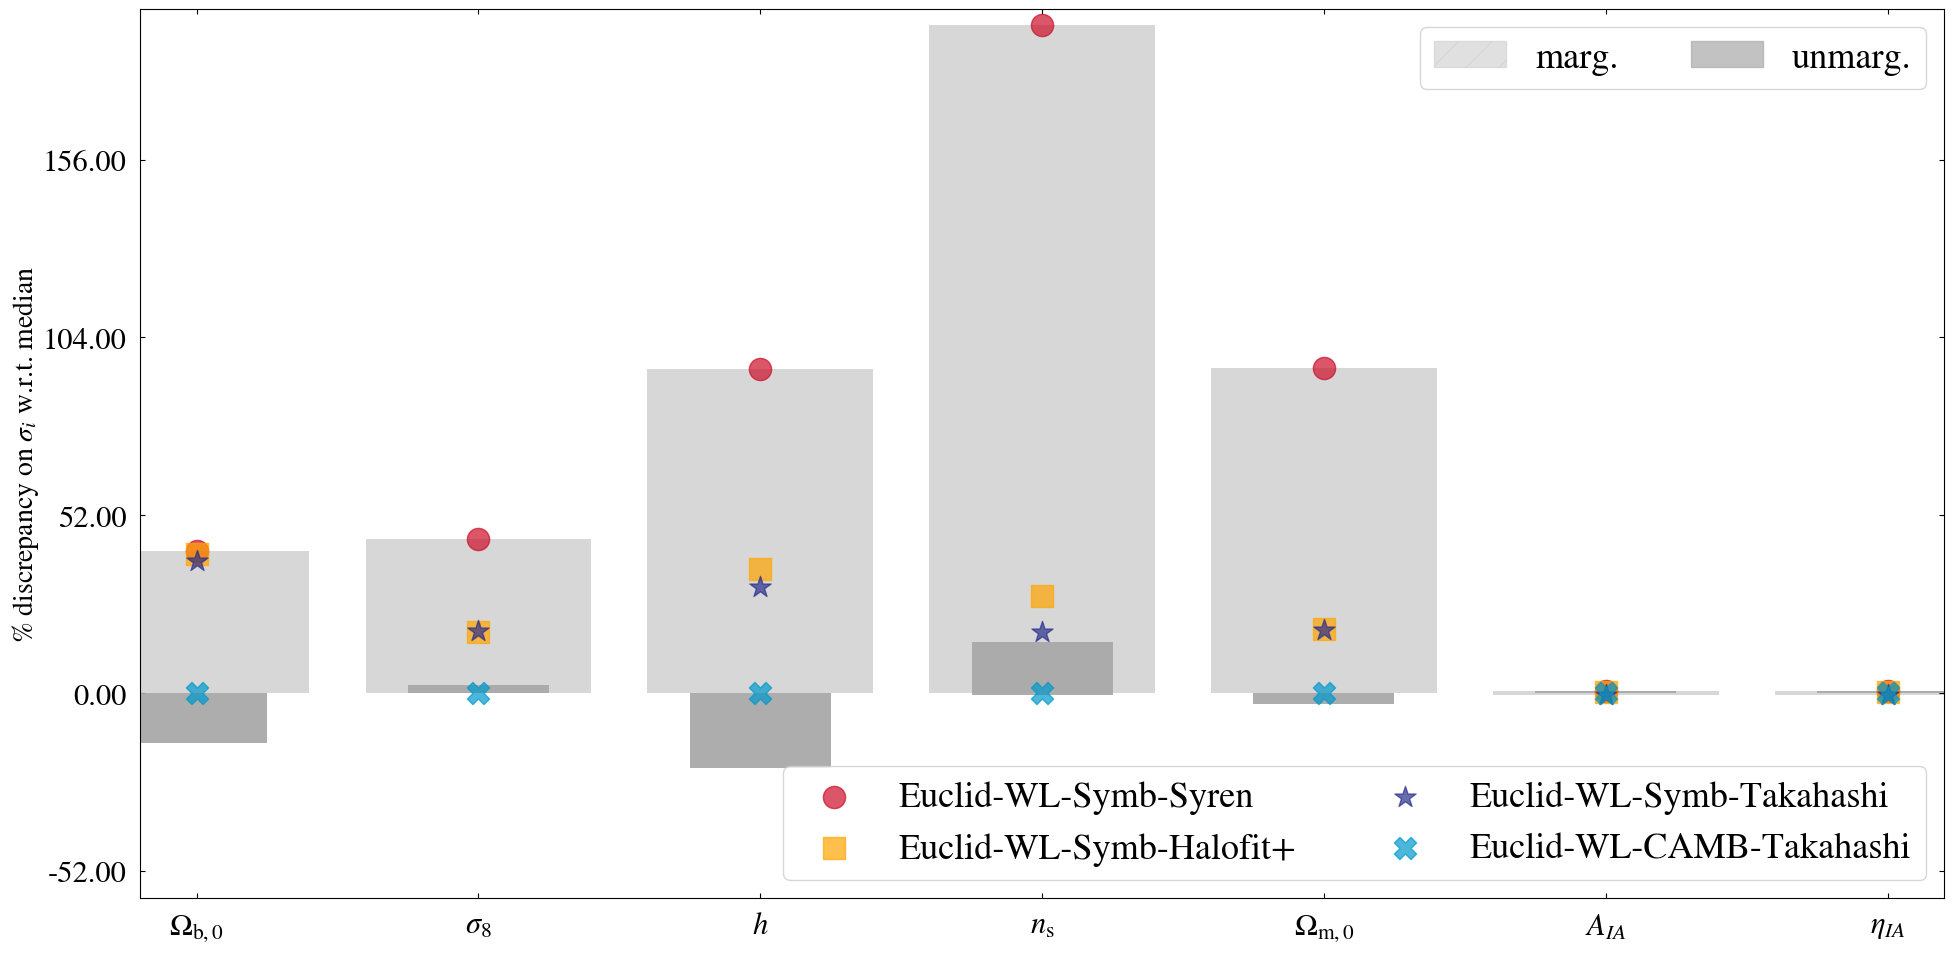

In [18]:
fish_plotter.compare_errors({'yrang' : [-60, 200], 'ncol_legend': 2, 'compare_to_index':3})

## Compare Derivatives

/tmp/ipykernel_37017/3178108435.py:22: RuntimeWarning: invalid value encountered in divide
  ratio = np.abs((dPdtheta_symb_syren[ii])/ dPdtheta_symb_taka[ii])
/tmp/ipykernel_37017/3178108435.py:24: RuntimeWarning: invalid value encountered in divide
  ratio = np.abs((dPdtheta_symb_hfp[ii])/ dPdtheta_symb_taka[ii])


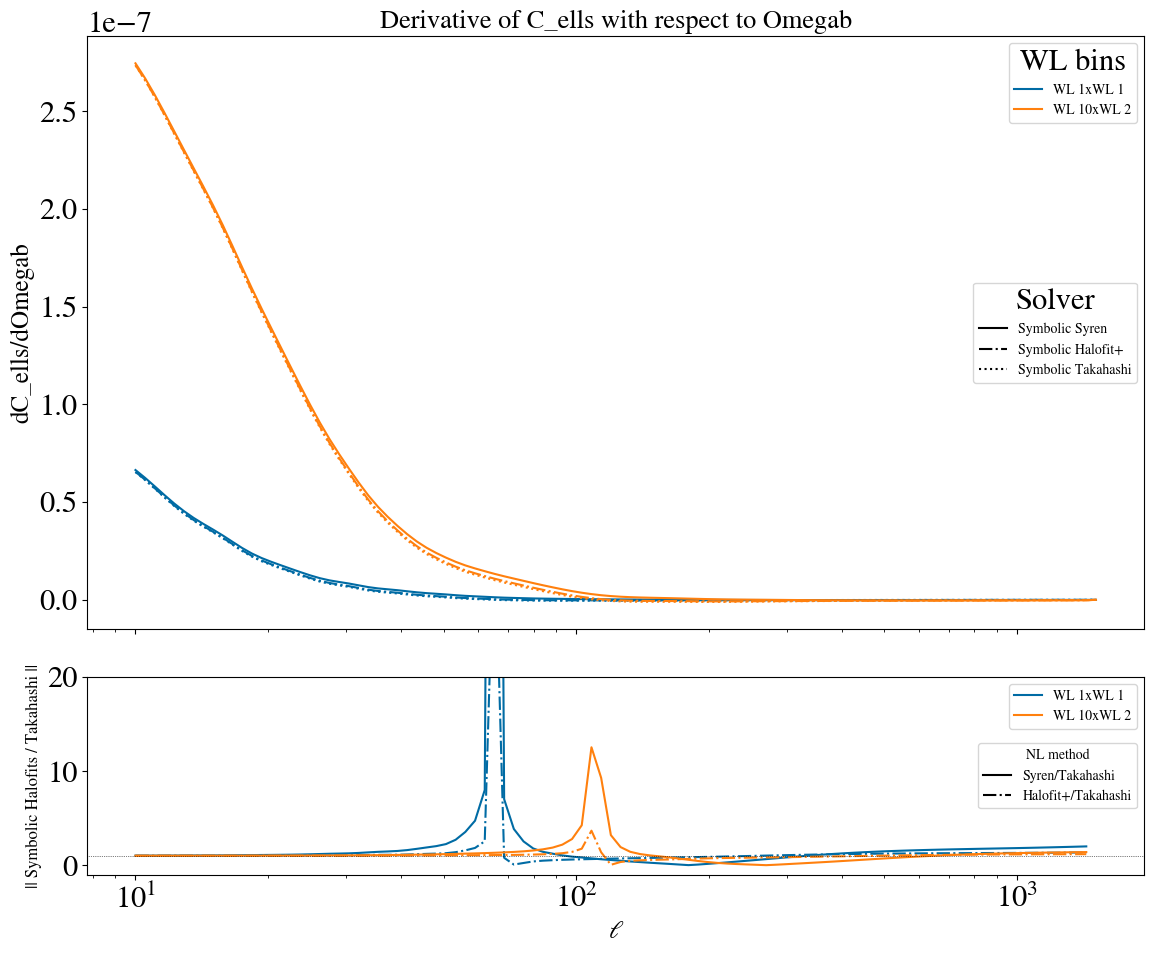

In [19]:
from matplotlib.lines import Line2D

variable = 'Omegab'

ells = cosmo_symb['WL_syren'].photo_derivs[variable]['ells']
binslist = ['WL 1xWL 1', 'WL 10xWL 2']
#dPdtheta_camb = [cosmo_camb['WL'].photo_derivs[variable][ii] for ii in binslist]
dPdtheta_symb_syren = [cosmo_symb['WL_syren'].photo_derivs[variable][ii] for ii in binslist]
dPdtheta_symb_hfp = [cosmo_symb['WL_halofit+'].photo_derivs[variable][ii] for ii in binslist]
dPdtheta_symb_taka = [cosmo_symb['WL_default'].photo_derivs[variable][ii] for ii in binslist]

# Create figure and axis objects
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot the data
for ii, zz in enumerate(binslist):
#    ax1.semilogx(ells, dPdtheta_camb[ii], ls='-', color=f'C{ii}')
    ax1.semilogx(ells, dPdtheta_symb_syren[ii], ls='-', color=f'C{ii}', label=f'{zz}')
    ax1.semilogx(ells, dPdtheta_symb_hfp[ii], ls='-.', color=f'C{ii}')
    ax1.semilogx(ells, dPdtheta_symb_taka[ii], ls=':', color=f'C{ii}')
    # Calculate and plot the ratio
    ratio = np.abs((dPdtheta_symb_syren[ii])/ dPdtheta_symb_taka[ii])
    ax2.semilogx(ells, ratio, color=f'C{ii}', ls='-', label=f'{zz}')
    ratio = np.abs((dPdtheta_symb_hfp[ii])/ dPdtheta_symb_taka[ii])
    ax2.semilogx(ells, ratio, color=f'C{ii}', ls='-.')
    #ratio = np.abs((dPdtheta_camb[ii])/ dPdtheta_symb_taka[ii])
    #ax2.semilogx(ells, ratio, color=f'C{ii}', label=f'{zz}')

# Create custom legend for CAMB and Symbolic
solver_legend_elements = [
    #Line2D([0], [0], color='black', ls='-', label='CAMB'),
    Line2D([0], [0], color='black', ls='-', label='Symbolic Syren'),
    Line2D([0], [0], color='black', ls='-.', label='Symbolic Halofit+'),
    Line2D([0], [0], color='black', ls=':', label='Symbolic Takahashi')
]
solver_legend = ax1.legend(handles=solver_legend_elements, loc='center right', title='Solver', fontsize=10)

# Add the solver legend to the plot
ax1.add_artist(solver_legend)

# Create legend for redshift values
z_legend = ax1.legend(title='WL bins', loc='upper right', fontsize=10)

# Set labels and title for the main plot
ax1.set_ylabel(f'dC_ells/d{variable}', fontsize=18)
ax1.set_title(f'Derivative of C_ells with respect to {variable}', fontsize=19)

solver2_legend_elements = [
    #Line2D([0], [0], color='black', ls='-', label='CAMB'),
    Line2D([0], [0], color='black', ls='-', label='Syren/Takahashi'),
    Line2D([0], [0], color='black', ls='-.', label='Halofit+/Takahashi'),
]
solver_legend2 = ax2.legend(handles=solver2_legend_elements, loc='center right', title='NL method', fontsize=10, title_fontsize=10)
ax2.add_artist(solver_legend2)
ax2.legend(fontsize=10, title_fontsize=10)
# Set labels for the ratio plot
ax2.set_xlabel(r'$\ell$', fontsize=18)
ax2.set_ylabel(r'|| Symbolic Halofits / Takahashi ||', fontsize=12)

# Add a horizontal line at y=1 for reference in the ratio plot
ax2.axhline(y=1, color='black', linestyle=':', linewidth=0.5)

# Set y-limits for the ratio plot (adjust as needed)
ax2.set_ylim(-1, 20)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()